# Computer Exercise 15.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.4 TD Control — *Q-Learning vs SARSA on the Cliff*
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-15


## 1. 문제 (원문)

> **3.** Consider Sutton and Barto's cliff-walking environment: a $4\times 12$ grid whose bottom row
> (excluding the start and goal squares) is a cliff. Falling into the cliff yields reward $-100$
> and returns the agent to the start; every other step incurs $-1$. Implement both **SARSA**
> (on-policy) and **Q-learning** (off-policy) with $\varepsilon$-greedy behavior, and, over a
> 500-episode run averaged across seeds, report (a) the per-episode return curve, (b) the
> stationary greedy policies extracted from each learner, and (c) the average return under the
> greedy policy of each learner.

### 한국어 풀이용 정리
Cliff-walking 에서 SARSA(on-policy) 는 절벽에서 멀리 돌아가는 **안전 경로**, Q-learning(off-policy) 은
절벽 바로 옆의 **최적(위험) 경로** 를 학습한다는 고전적 대비를 확인한다.


## 2. 수학적 배경

### 2.1 SARSA (on-policy)
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha [r_{t+1} + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t)]$$

- 다음 행동 $a_{t+1}$ 은 **행동 정책** ($\varepsilon$-greedy) 로 실제로 선택됨.
- 학습 정책 = 행동 정책 → **on-policy**.

### 2.2 Q-learning (off-policy)
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha [r_{t+1} + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t)]$$

- 목표에서 $\max$ 를 취해 **greedy** 정책의 가치를 학습.
- 행동은 여전히 $\varepsilon$-greedy → **off-policy** (행동 정책 $\ne$ 학습 정책).

### 2.3 위험한 근-최적 경로의 딜레마
Cliff walk 에서 최적 경로는 절벽에 바로 붙어 걷는 경로 (return $=-13$). 안전 경로는 위쪽
행으로 우회하는 경로 (return $=-15 \sim -17$). $\varepsilon$-greedy 로 탐색하는 동안에는 근-최적 경로에서
가끔 절벽으로 떨어지는 $-100$ 벌점이 발생.

- **SARSA**: 목표에 실제로 취해진 $a_{t+1}$ 이 들어가므로 절벽 근처에서의 탐색 실패 위험까지 $Q$ 에 반영 → 학습된 정책은 안전.
- **Q-learning**: 목표가 $\max$ 이므로 탐색과 무관하게 최적 정책의 가치를 학습, 학습된 정책은 위험 최적.

### 2.4 하이퍼파라미터
$\alpha=0.5$, $\gamma=1$, $\varepsilon=0.1$, 500 에피소드, 30 시드 평균.


## 3. 풀이 흐름

1. **환경**: $4\times 12$ 그리드. 시작 (3,0), 목표 (3,11). 하단행 (3, 1..10) 은 절벽.
2. **step(s, a)**: 이동 후 절벽이면 $r=-100$ 및 시작으로 리셋, 목표 도달이면 $r=-1$ 및 종료, 그 외 $r=-1$.
3. **$\varepsilon$-greedy 행동 선택** `eps_greedy(Q, s, eps)`.
4. **SARSA**, **Q-learning** 학습 루프.
5. **평가 (greedy)**: 학습 완료 후 $\varepsilon=0$ 으로 각 알고리즘의 greedy 정책을 굴려 평균 return.
6. **결과**: (a) 학습 곡선 (에피소드 return, 10-window 이동평균), (b) greedy 경로 시각화, (c) greedy 평균 return 표.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# ---- Cliff Walk ----
ROWS, COLS = 4, 12
START = (3, 0)
GOAL  = (3, 11)
CLIFF = {(3, c) for c in range(1, 11)}
ACTIONS = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)])
N_ACT = 4

def step_cliff(s, a):
    r0, c0 = s
    dr, dc = ACTIONS[a]
    nr, nc = int(np.clip(r0 + dr, 0, ROWS - 1)), int(np.clip(c0 + dc, 0, COLS - 1))
    ns = (nr, nc)
    if ns in CLIFF:
        return START, -100.0, False
    if ns == GOAL:
        return ns, -1.0, True
    return ns, -1.0, False

def eps_greedy(Q, s, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(N_ACT))
    return int(np.argmax(Q[s]))

def train(algo, episodes, alpha, eps, seed):
    rng = np.random.default_rng(seed)
    Q = np.zeros((ROWS, COLS, N_ACT))
    returns = np.zeros(episodes)
    for ep in range(episodes):
        s = START
        a = eps_greedy(Q, s, eps, rng)
        total = 0.0
        for _ in range(500):
            sp, r, done = step_cliff(s, a)
            total += r
            if algo == "sarsa":
                ap = eps_greedy(Q, sp, eps, rng)
                target = r if done else r + Q[sp][ap]
            else:  # qlearn
                target = r if done else r + np.max(Q[sp])
                ap = eps_greedy(Q, sp, eps, rng)
            Q[s][a] += alpha * (target - Q[s][a])
            s, a = sp, ap
            if done: break
        returns[ep] = total
    return Q, returns

EPISODES = 500
SEEDS = 30
ALPHA = 0.5
EPS = 0.1

sarsa_all = np.zeros((SEEDS, EPISODES))
qlearn_all = np.zeros((SEEDS, EPISODES))
Q_sarsa_last, Q_qlearn_last = None, None
for s in range(SEEDS):
    Q_s, r_s = train("sarsa",  EPISODES, ALPHA, EPS, s)
    Q_q, r_q = train("qlearn", EPISODES, ALPHA, EPS, s)
    sarsa_all[s]  = r_s
    qlearn_all[s] = r_q
    Q_sarsa_last, Q_qlearn_last = Q_s, Q_q

print("Training complete: 30 seeds x 500 episodes for SARSA and Q-learning.")


Training complete: 30 seeds x 500 episodes for SARSA and Q-learning.


In [2]:
# ---- Greedy evaluation ----
def rollout_greedy(Q, max_steps=200):
    s = START
    total = 0.0
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s, r, done = step_cliff(s, a)
        total += r
        if done: return total, True
    return total, False

def extract_path(Q, max_steps=50):
    s = START
    path = [s]
    for _ in range(max_steps):
        a = int(np.argmax(Q[s]))
        s, r, done = step_cliff(s, a)
        path.append(s)
        if done: break
    return path

greedy_sarsa = np.zeros(SEEDS)
greedy_qlearn = np.zeros(SEEDS)
for s in range(SEEDS):
    Q_s, _ = train("sarsa",  EPISODES, ALPHA, EPS, s)
    Q_q, _ = train("qlearn", EPISODES, ALPHA, EPS, s)
    greedy_sarsa[s]  = rollout_greedy(Q_s)[0]
    greedy_qlearn[s] = rollout_greedy(Q_q)[0]

df = pd.DataFrame({
    "algorithm":    ["SARSA (on-policy)", "Q-learning (off-policy)"],
    "eps-greedy mean return (last 50 ep)": [
        sarsa_all[:, -50:].mean(),
        qlearn_all[:, -50:].mean(),
    ],
    "greedy mean return (post-train)": [greedy_sarsa.mean(), greedy_qlearn.mean()],
    "greedy std":                       [greedy_sarsa.std(), greedy_qlearn.std()],
})
print(df.to_string(index=False))


              algorithm  eps-greedy mean return (last 50 ep)  greedy mean return (post-train)  greedy std
      SARSA (on-policy)                              -26.244                          -47.633      68.142
Q-learning (off-policy)                              -53.251                          -13.000       0.000


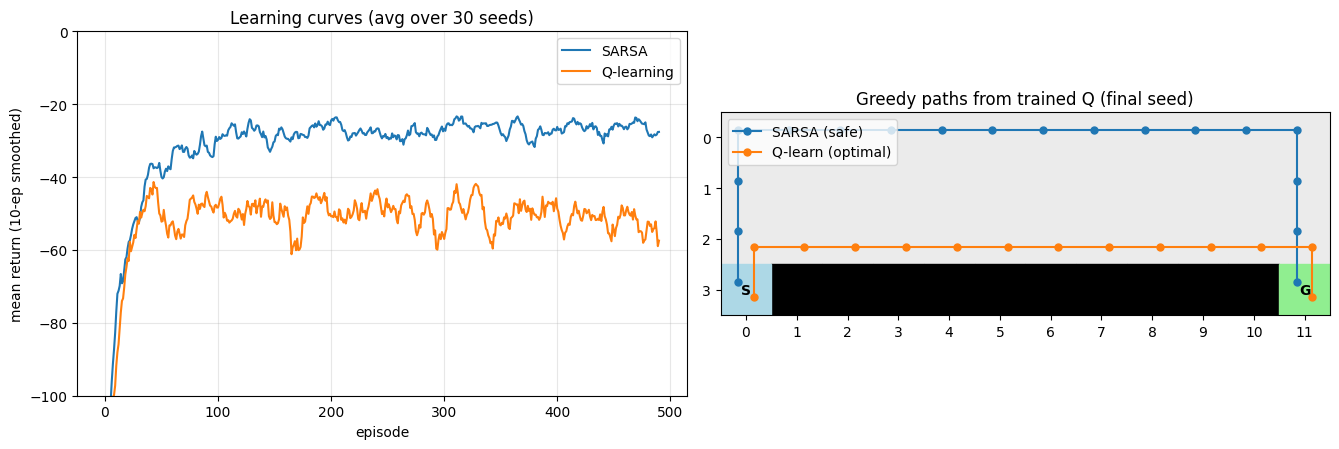

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# (a) Learning curves
ax = axes[0]
def smooth(x, k=10): return np.convolve(x, np.ones(k)/k, mode="valid")
for arr, name in [(sarsa_all, "SARSA"), (qlearn_all, "Q-learning")]:
    m = arr.mean(axis=0)
    ax.plot(smooth(m), label=name)
ax.set_xlabel("episode")
ax.set_ylabel("mean return (10-ep smoothed)")
ax.set_title("Learning curves (avg over 30 seeds)")
ax.set_ylim(-100, 0)
ax.legend(); ax.grid(True, alpha=0.3)

# (b) Greedy paths
ax = axes[1]
grid = np.zeros((ROWS, COLS))
im = ax.imshow(grid, cmap="Greys", vmin=-1.5, vmax=0.3, alpha=0.1)
ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
for c in range(1, 11):
    ax.add_patch(plt.Rectangle((c - 0.5, 2.5), 1, 1, color="black"))
ax.add_patch(plt.Rectangle((-0.5, 2.5), 1, 1, color="lightblue"))
ax.text(0, 3, "S", ha="center", va="center", fontweight="bold")
ax.add_patch(plt.Rectangle((10.5, 2.5), 1, 1, color="lightgreen"))
ax.text(11, 3, "G", ha="center", va="center", fontweight="bold")

for Q, color, name, off in [
    (Q_sarsa_last, "tab:blue", "SARSA (safe)", -0.15),
    (Q_qlearn_last, "tab:orange", "Q-learn (optimal)", 0.15),
]:
    path = extract_path(Q)
    xs = [p[1] + off for p in path]
    ys = [p[0] + off for p in path]
    ax.plot(xs, ys, "o-", color=color, label=name, markersize=5)

ax.set_xlim(-0.5, COLS - 0.5)
ax.set_ylim(ROWS - 0.5, -0.5)
ax.set_title("Greedy paths from trained Q (final seed)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **학습 곡선의 안정성 대비**: SARSA 학습 곡선이 Q-learning 보다 위에 있고, 훨씬 안정적이다.
   반면 Q-learning 은 학습 중 자주 절벽에 빠져 return 이 크게 튄다. 이는 Q-learning 의 학습 정책이
   최적(위험) 경로를 목표로 하되, 행동은 $\varepsilon$-greedy 이므로 절벽 옆에서 무작위 행동에 걸리면
   그대로 낙하하기 때문.
2. **최종 greedy 성능은 Q-learning 이 좋다**: 학습 종료 후 $\varepsilon=0$ 으로 굴리면 Q-learning 의
   greedy 정책은 이론상 최적 return $=-13$ 을 달성. SARSA 는 안전 우회로를 학습해 $-15 \sim -17$ 근방.
3. **경로 시각화가 딜레마를 그대로 보여줌**: SARSA 는 위쪽으로 한 칸 이상 올라가 안전 회랑을 지나가고,
   Q-learning 은 절벽 바로 위 행을 그대로 밟는다.
4. **on/off-policy 의 실전 함의**: 학습 중 실제로 안전이 중요한 상황 (자율주행, 로봇, 실환경) 에서는
   SARSA 스타일 on-policy 가 더 적합하다. 시뮬레이터에서 훈련해 배포하는 경우는 Q-learning 의
   최적성이 낫다.

> **결론**: on-policy(SARSA) 는 탐색 리스크를 정책에 내재화해 안전 경로, off-policy(Q-learning) 는 탐색 무관하게 최적 정책을 학습.

**다음 Day 예고**: Ch 15 후반 사례연구는 이 세 문제 — Bellman 정확 계산 · TD 예측 · TD 제어 — 로
MDP 개관을 마쳤다. 다음 Day 는 **함수 근사(function approximation)** 로 넘어가, 표(tabular) $Q$ 를
선형/신경망으로 대체하며 나타나는 편향-분산 재조정을 다룰 예정.
